In [2]:
# Example loading and plotting lidar data of Hybrid Dune Campaign

import numpy as np 
import xarray as xr
import os   
from datetime import datetime
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.dates as mdates
import matplotlib as mpl
from scipy.ndimage import gaussian_filter1d
from scipy.signal import savgol_filter
from netCDF4 import Dataset
import warnings

import sys
sys.path.append('../functions')
from convert_lidar_coordinates_ds_single import convert_lidar_coordinates_ds


File structure 
1) function: filter pointcloud
2) load and filter pointcloud
3) split in 10min blocks, determine rmax = r99%_10min.     every 10min? or every minute?
4) split in 1min blocks. Determine r50%, r90%, r99%
5) filter: use r_90 where likely dry. interpolate/fill gaps. 
6) find slumping events. E.g. >0.1 m³/m erosion between previous and next t, between z=2.5 and z=4.5
7) Calculate new r_max for the 10 minute before and after slumping event
8) if no slumping AND (r_max - r_90%)>5 cm for some angle, replace with r_max

In [3]:
## 0) FUNCTION TO COMPUTE PERCENTILES UNAFFECTED BY NaNs
def percentile_nans_lowest(data, percentile, *, axis=None, method="linear"):
    """
    Compute percentiles treating NaNs as the lowest-ranked values, preserving array size and never returning -inf.
    So given 10 minutes of data, the 90th percentile is exceeded for 1 minute, irrespective of the number of nans.

    Parameters
    ----------
    data : array_like. Input data.
    percentile : float or array_like. Percentile(s) in [0, 100].
    axis : int or tuple of int, optional. Axis or axes along which the percentiles are computed. Default is None (flattened array).
    method : str, optional. Quantile interpolation method (passed to np.quantile).

    Returns
    -------
    percentile_values : ndarray
        Percentile values. Positions corresponding to NaN-only percentiles return np.nan.
    """
    data = np.asarray(data)
    p = np.asarray(percentile) / 100.0                          # convert to quantiles

    # Count NaNs along the axis
    nan_count = np.sum(np.isnan(data), axis=axis, keepdims=True)
    total_count = np.size(data, axis=axis)

    # All-NaN slices → return NaN
    if axis is None:
        if nan_count == total_count:
            return np.nan
    else:
        all_nan_mask = (nan_count == total_count)

    filled = np.nan_to_num(data, nan=-np.inf)                    # Replace NaNs with -inf for ranking only
    result = np.quantile(filled, p, axis=axis, method=method)    # Compute quantiles
    result = np.where(np.isneginf(result), np.nan, result)       # Replace -inf outputs with NaN

    # Handle all-NaN slices (for axis case)
    if axis is not None:
        result = np.where(all_nan_mask.squeeze(axis), np.nan, result)

    return result

In [4]:
## 1) FUNCTION TO LOAD AND FILTER LIDAR DATA
def filter_pointcloud(nc_in, n_lidar, n_storm, t_sel=None, profile_isel=None, i_obs_start=361, i_obs_end=545):
    # Load pointcloud and convert to local coordinates. Filter cloud by deleting the mounting frame from the cloud, as well as high points that are waves/rain/...  
    # i_obs_start = 361  is straight under the lidar. i_obs_start = 545 for the later storms, when the dune toe is further seaward. i_obs_end = 545 # for 93deg

    # Define frame angles to be skipped
    # Initialize the array: shape (3, 2, 4, 3) for 3 skip_regions × 2 limits (start_stop) × 4 lidars × 3 storms
    hoek_frame_skip = np.zeros((3, 2, 4, 3))
    # S1
    hoek_frame_skip[:, :, 0, 0] = [[-17.4, -14.9], [-13.8, -10.9], [-2.75, 0]]   # storm 1
    hoek_frame_skip[:, :, 0, 1] = [[-16.9, -13.9], [-13.3, -9.9], [-2.25, 0.5]]  # storm 2
    hoek_frame_skip[:, :, 0, 2] = [[-17.4, -14.4], [-13.8, -10.9], [-2.75, 0]]   # storm 3

    # S2
    hoek_frame_skip[:, :, 1, 0] = [[-21.2, -18.2], [-14.3, -11.3], [-2.3, 0.7]]
    hoek_frame_skip[:, :, 1, 1] = [[-20.2, -17.7], [-13.8, -10.8], [-1.3, 1.7]]
    hoek_frame_skip[:, :, 1, 2] = [[-21.2, -18.2], [-14.3, -11.8], [-2.3, 0.7]]

    # S3
    hoek_frame_skip[:, :, 2, 0] = [[-17.0, -14.5], [-12.5, -9.5], [1.0, 4.0]]
    hoek_frame_skip[:, :, 2, 1] = [[-17.0, -14.5], [-12.5, -9.5], [1.0, 4.0]]
    hoek_frame_skip[:, :, 2, 2] = [[-17.5, -14.5], [-12.5, -10.0], [0.5, 4.0]]

    # S4
    hoek_frame_skip[:, :, 3, 0] = [[-19.25, -16.25], [-11.25, -8.75], [-2.75, 0.25]]
    hoek_frame_skip[:, :, 3, 1] = [[-19.25, -16.25], [-11.25, -8.75], [-2.75, 0.25]]
    hoek_frame_skip[:, :, 3, 2] = [[-19.75, -16.75], [-11.75, -8.75], [-3.25, -0.25]]

        # # determine limits to load data from: which vertical angles to select. Between -90° and 105°
        # ds = xr.open_dataset(nc_in).isel(profile_number=0, t=0, echos=0)   # select specific time range: t0 until t_end

        # # # find obs_number with -90° < beam_angle < 105°
        # i_obs_start = np.where(ds.beam_angle.values > -90)[0][0]
        # i_obs_end = np.where(ds.beam_angle.values < 93)[0][-1]
        # print(i_obs_end)



    # load data with these obs_number limits
    if (t_sel is  None) and (profile_isel is None):
        ds = xr.open_dataset(nc_in).isel(obs_number=slice(i_obs_start, i_obs_end))                                            # select specific angles
    elif t_sel is None:
        ds = xr.open_dataset(nc_in).isel(profile_number=profile_isel, obs_number=slice(i_obs_start, i_obs_end))               # select specific angles and profile
    elif profile_isel is None:
        ds = xr.open_dataset(nc_in).sel(t=t_sel).isel(obs_number=slice(i_obs_start, i_obs_end))                               # select specific angles and time range
    else:
        ds = xr.open_dataset(nc_in).sel(t=t_sel).isel(profile_number=profile_isel, obs_number=slice(i_obs_start, i_obs_end))  # select specific angles, profile and time range

    # Filter out the frame -----------------------------------------------------------------------
    # Filter out the frame by replacing values in ds.beam_angle with NaN where the laser sees the frame. Then use filtered beam angles for coordinate conversion.

    # Select the slice for given n_lidar and n_storm (Python: 0-based)
    # Example: n_lidar = 1, n_storm = 2 (MATLAB) -> Python: 0, 1
    hoek_frame_skip_slice = hoek_frame_skip[:, :, n_lidar-1, n_storm-1] 

    # Filter frame: loop, for every row in hoek_frame_skip_slice, make angles nan where angles>value_col_1 and angles<value_col_2
    angles = ds.beam_angle.values

    for row in hoek_frame_skip_slice:
        angles[(angles > row[0]) & (angles < row[1])] = np.nan

    ds.beam_angle.values = angles   

    # Convert to local coordinates
    ds = convert_lidar_coordinates_ds(ds, 'local', max_echos=True, keep_I=False, keep_r=True, keep_y=False) # skip intensity, take max distance of echos

    # Define skip area (to remove points below x=6m and above z=-1m)
    x_skip_area = 6.5   # delete every point that is less than 6 m landward of lidar, and (simultaneously) less than 1 m below the lidar
    z_skip_area = -1
    x_min = ds.x_i_local.values + x_skip_area
    z_max = ds.z_i.values + z_skip_area

    # make x, y, z values nan where (x < x_skip_area) & (z > z_skip_area)
    mask_keep = (ds.x.values > x_min) | (ds.z.values < z_max) # keep where either condition is met. So remove where <x_lmin and >z_max
    ds['x'] = ds.x.where(mask_keep)
    #ds['y'] = ds.y.where(mask_keep)
    ds['z'] = ds.z.where(mask_keep)
    ds['radius_lidar'] = ds.radius_lidar.where(mask_keep)

    return ds


In [5]:
## 2) LOAD AND FILTER LIDAR DATA
# INPUT PARAMETERS ------------------------------------------------------------------------------------------------
n_lidar = 2  # set as needed (1-based, like MATLAB)
i_obs_start_all = [420, 500, 500] # for 3 storms
for n_storm in [2]: #[1, 2, 3]:
#n_storm = 1 # set as needed (1-based, like MATLAB)

    nc_in = fr"C:\Users\dpoppema\OneDrive - Delft University of Technology\dataset_hybrid_dune\Lidar\data\S{n_lidar} Lidar, storm{n_storm}.nc"
    if n_storm == 1:
        t1 = pd.Timestamp('19-12-2024 00:02') # was 2:00
        t2 = pd.Timestamp('19-12-2024 22:00') # was 19dec 22:00
    elif n_storm == 2:
        t1 = pd.Timestamp('22-12-2024 04:00')
        t2 = pd.Timestamp('22-12-2024 23:10')
    elif n_storm == 3:
        t1 = np.datetime64('2025-01-01T12:00')
        t2 = np.datetime64('2025-01-02T09:09')  # ensure that Jan 2 is selected, not Feb 1
    else:
        raise ValueError('n_storm must be 1, 2, or 3')

    # LOAD AND FILTER POINTCLOUD ----------------------------------------------------------------------------------------
    i_obs_start = i_obs_start_all[n_storm-1] # Python: 0-based indexing
    ds = filter_pointcloud(nc_in, n_lidar, n_storm, t_sel=slice(t1, t2), profile_isel=2, i_obs_start=i_obs_start ) # Filter out frame and high waves (points less than 1 m below lidar and offshore of dune toe)    
    ds = ds.drop_vars(['x','z'])

# MAKE T SPACING EXACTLY 0.25S ------------------------------------------------------------------------------------------
# Times are snapped to the nearest 0.25s, times without nearby value get nan. No interpolation/resampling is done. So timeseries get distorted slightly, but that does not matter for profiles, where we look at moving averages etc anyway. 
t = pd.to_datetime(ds.t.values)                                                         # original time values
t_new = pd.date_range(t.min().ceil("250ms"), t.max().floor("250ms"), freq="250ms")      # uniform time grid with 0.25s spacing
idx = pd.Index(t_new).get_indexer(t, method="nearest")                                  # Compute nearest indices for t on target grid

r_new = xr.DataArray( np.full((ds.sizes["obs_number"], len(t_new)), np.nan),            # build empty array for r with uniform time spacing
                      dims=("obs_number", "t"),
                      coords={"obs_number": ds.obs_number, "t": t_new}   )
r_new.values[:, idx] = ds.radius_lidar.values                                           # fill. If collisions happen, later ones overwrite earlier ones

# update ds in-place
ds = ds.drop_dims("t")
ds = ds.assign_coords(t=t_new)
ds["radius_lidar"] = r_new

In [6]:
## 3) DETERMINE r99%_10min 
# Calculate the 99th percentile of r over 10-minute windows. Do this every minute, with a window centered on that minute

# Settings ------------------------------------------------------------------------------------------------------
sf = float(ds.sf.values)
if sf != 4.0:   # Temp code: sampling frequency of storm 2, lidar 2 is incorrect, at 0.1 Hz instead of 4 Hz
    warnings.warn(f"sf = {sf} instead of 4. Correct NetCDF! Using sf=4 for now")
    sf = 4
win_len = int(10 * 60 * sf)   # 10 min in samples
step = int(60 * sf)           # 1 min in samples

# Build strided window view of r, for fast computation of percentiles over the windows.---------------------------
#r = ds.radius_lidar.transpose("obs_number", "t")  # ensure shape is (obs_number, t)
arr = ds.radius_lidar.values
n_obs, n_t = arr.shape

# number of windows
n_win = (n_t - win_len) // step + 1
if n_win <= 0:
    raise ValueError("Not enough samples for a 10-min window.")

# build strided window view: (obs_number, window, sample)
s0, s1 = arr.strides
windows = np.lib.stride_tricks.as_strided( arr,
                                           shape=(n_obs, n_win, win_len),
                                           strides=(s0, step * s1, s1),
                                           writeable=False )

# Calculate 99th percentile over the window samples -------------------------------------------------------------
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=RuntimeWarning, message="All-NaN slice encountered")
    #p99 = np.nanpercentile(windows, 99, axis=-1)  # shape: (obs, n_win)
    p99 = percentile_nans_lowest(windows, 99, axis=-1)  # shape: (obs, n_win)

# center times for each window (one per minute)
t_vals = pd.to_datetime(ds.t.values)
center_idx = np.arange(n_win) * step + win_len // 2
t_center = t_vals[center_idx].round('1s')  # Round, in some cases the timestamp is 0.25s or 1s off.

# wrap back to xarray
r99_10min = xr.DataArray( p99,
                          dims=("obs_number", "minute"),
                          coords={"obs_number": ds.obs_number, "minute": t_center}  )

# Save result to Xarray Dataset --------
# Define a new ds_profiles: a copy of ds, without the coordinate t, and with r_final as radius_lidar
ds_profiles99_10min = ds.drop_dims("t")  # drop t dimension
ds_profiles99_10min['radius_lidar'] = r99_10min  # Assign r_final as the new radius_lidar. Var name must be radius_lidar for convert_lidar_coordinates_ds

ds_profiles99_10min = convert_lidar_coordinates_ds(ds_profiles99_10min, 'local', max_echos=False, keep_I=False, keep_r=True, keep_y=False) # skip intensity. Max echos already taken, not needed again

C:\Users\dpoppema\AppData\Local\Temp\ipykernel_15712\1485996513.py:7: UserWarning: sf = 0.1 instead of 4. Correct NetCDF! Using sf=4 for now
  warnings.warn(f"sf = {sf} instead of 4. Correct NetCDF! Using sf=4 for now")


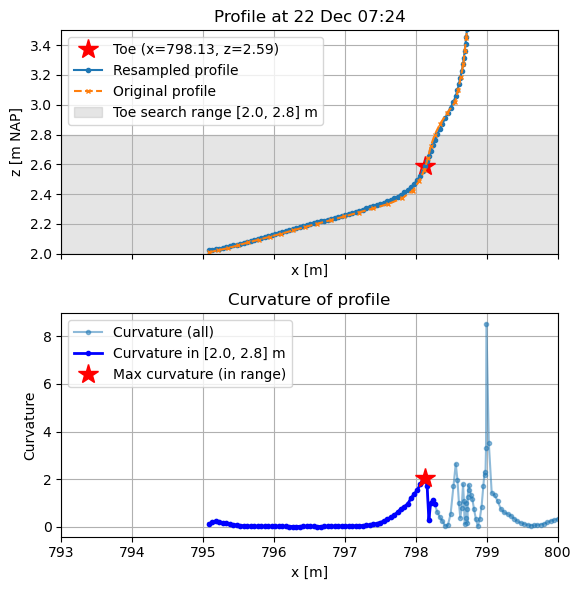

In [7]:
#  TOE ESTIMATION BASED ON SMOOTHED PROFILES

# Estimate toe location: Find location of maximum curvature along each profile. based on 10min windows
# Settings ---------------------------------------------------------------------------------------
x_vals = ds_profiles99_10min.x.values
z_vals = ds_profiles99_10min.z.values

minutes_smoothing = 10  # in minutes, for Gaussian smoothing over time. Set to 0 to skip 
dt_minutes = 1 # time step between profiles

# Define elevation range for toe search [m NAP]
z_min_toe = 2.0   # storm 1
z_max_toe_all = [2.8, 2.8, 3]
z_max_toe = z_max_toe_all[n_storm-1] # Python: 0-based indexing

# Target spacing along the arc length [m]
dl_target = 0.05 # [m]
dl_smoothing = 0.2 # for Gaussian smoothing over space, after profile is interpolated.  [m]

# Function definion ---------------------------------------------------------------------------------------
# Define fucntion to resample a single profile for roughly constant spacing along its arc length and compute its curvature
def resample_profile(x_profile, z_profile, dl_target, dl_smoothing):
    """Interpolate the profile so points are roughly dl_target apart along the curve."""
    valid_mask = ~(np.isnan(x_profile) | np.isnan(z_profile))
    if valid_mask.sum() < 3:
        return None

    # Keep only valid points and compute cumulative arc length
    x_valid = x_profile[valid_mask]
    z_valid = z_profile[valid_mask]
    tangential_diffs = np.sqrt(np.diff(x_valid)**2 + np.diff(z_valid)**2)
    if tangential_diffs.size == 0:
        return None

    s_profile = np.concatenate(([0.0], np.cumsum(tangential_diffs)))
    total_length = s_profile[-1]
    if total_length <= 0:
        return None

    # Create a uniform grid along the arc length
    n_target = max(int(np.ceil(total_length / dl_target)) + 1, 3)
    s_uniform = np.linspace(0.0, total_length, n_target)

    # Interpolate x/z as functions of arc length
    x_interp = np.interp(s_uniform, s_profile, x_valid)
    z_interp = np.interp(s_uniform, s_profile, z_valid)
    ds_step = s_uniform[1] - s_uniform[0]

    # Optional Gaussian smoothing along the arc length
    if dl_smoothing is not None and dl_smoothing > 0:
        sigma_samples = dl_smoothing / ds_step
        #x_interp = gaussian_filter1d(x_interp, sigma=sigma_samples, mode='nearest')
        z_interp = gaussian_filter1d(z_interp, sigma=sigma_samples, mode='nearest')

    return x_interp, z_interp, ds_step

def extract_toe_curvature(x, z, dl_target, dl_smoothing, z_min_toe, z_max_toe):
    # Resample and smooth the profile along its arc length, to get constant spacing and reduce noise
    resampled = resample_profile(x, z, dl_target, dl_smoothing)
    if resampled is None:
        return None
    x_interp, z_interp, ds_step = resampled

    # Compute derivaties (first and second, with respect to arc length): needed for curvature
    dx_ds = np.gradient(x_interp, ds_step)  
    dz_ds = np.gradient(z_interp, ds_step)
    d2x_ds2 = np.gradient(dx_ds, ds_step)
    d2z_ds2 = np.gradient(dz_ds, ds_step)

    # Compute curvature using the formula: k = |x' z'' - z' x''| / (x'^2 + z'^2)^(3/2)
    numerator = np.abs(dx_ds * d2z_ds2 - dz_ds * d2x_ds2)
    denominator = (dx_ds**2 + dz_ds**2)**1.5
    curvature = np.full_like(numerator, np.nan)
    mask = denominator > 1e-12
    curvature[mask] = numerator[mask] / denominator[mask]

    # Mask curvature: only look for peaks in the target elevation range
    mask_range = (z_interp >= z_min_toe) & (z_interp <= z_max_toe)
    curvature_in_range = curvature.copy()
    curvature_in_range[~mask_range] = np.nan   
    if np.all(np.isnan(curvature_in_range)):
        return None

    # Find max curvature
    idx_local = np.nanargmax(curvature_in_range)
    x_toe = x_interp[idx_local]
    z_toe = z_interp[idx_local]
    curvature_max = curvature_in_range[idx_local]

    return x_toe, z_toe, x_interp, z_interp, curvature, curvature_in_range, curvature_max


# Calculation ---------------------------------------------------------------------------------------
# Prepare arrays to store toe estimates for each minute
n_minutes = x_vals.shape[1]
x_toe = np.full(n_minutes, np.nan)
z_toe = np.full(n_minutes, np.nan)
curvature_max = np.full(n_minutes, np.nan)

# Smooth the profiles over time using a Gaussian filter
sigma_samples = minutes_smoothing / dt_minutes  # convert smoothing width from minutes to number of samples
if sigma_samples > 0:
    z_smooth = gaussian_filter1d(z_vals, sigma=sigma_samples, axis=1, mode='reflect')
else:
    z_smooth = z_vals

# Loop over every profile and resample it to find the curvature peak inside the target elevation range
for minute_idx in range(n_minutes):
    # Resample and smooth the profile for this minute, and extract the toe based on curvature    
    toe = extract_toe_curvature(x_vals[:, minute_idx], z_smooth[:, minute_idx], dl_target, dl_smoothing, z_min_toe, z_max_toe)
    if toe is None:
        continue
    
    x_toe[minute_idx], z_toe[minute_idx], x_interp, z_interp, curvature_profile, curvature_in_range, curvature_max[minute_idx] = toe

# Store the new toe time series in the dataset 
ds_profiles99_10min["x_toe"] = ("minute", x_toe)
ds_profiles99_10min["z_toe"] = ("minute", z_toe)


# Plot: Example profile with slope and curvature ------------------------------------------
t_plot = pd.Timestamp('2024-12-22 07:24')
#t_plot = pd.Timestamp('2024-12-19 21:24')

minute_idx = np.argmin(np.abs(ds_profiles99_10min.minute.values - np.datetime64(t_plot))) # find closest time. NB: if t_plot is not updated with n_storm, this may be totally different.
t_plot = ds_profiles99_10min.minute.values[minute_idx]  # snap to actual time of profile, in case t_plot was off
t_plot = pd.Timestamp(t_plot)  # convert back to pandas Timestamp for nicer plotting

# Calculate curvature and toe of example profile
x_toe_plot, z_toe_plot, x_interp, z_interp, curvature_profile,curvature_in_range, curvature_max_plot = extract_toe_curvature(x_vals[:, minute_idx], z_smooth[:, minute_idx], dl_target, dl_smoothing, z_min_toe, z_max_toe)

fig, axs = plt.subplots(2, 1, figsize=(6, 6), sharex=True)

# Subplot 1: Profile with toe marked
ax = axs[0]
ax.plot(x_toe_plot, z_toe_plot, 'r*', markersize=15, label=f'Toe (x={x_toe_plot:.2f}, z={z_toe_plot:.2f})')
ax.plot(x_interp, z_interp, '-o', markersize=3, label='Resampled profile')
ax.plot(ds_profiles99_10min.x.values[:, minute_idx], ds_profiles99_10min.z.values[:, minute_idx], '--x', markersize=3, label='Original profile')
ax.axhspan(z_min_toe, z_max_toe, alpha=0.2, color='gray', label=f'Toe search range [{z_min_toe}, {z_max_toe}] m')
ax.set_xlabel('x [m]')
ax.set_ylabel('z [m NAP]')
ax.set_title(f'Profile at {t_plot.strftime("%d %b %H:%M")}')
ax.legend()
ax.grid()
ax.set_ylim([2, 3.5])

# Subplot 2: Curvature (with target elevation range highlighted)
ax = axs[1]
ax.plot(x_interp, curvature_profile, '-o', markersize=3, label='Curvature (all)', alpha=0.5)
ax.plot(x_interp, curvature_in_range, '-o', markersize=3, label=f'Curvature in [{z_min_toe}, {z_max_toe}] m', linewidth=2, color='blue')
ax.plot(x_toe_plot, curvature_max_plot, 'r*', markersize=15, label='Max curvature (in range)')

ax.set_xlabel('x [m]')
ax.set_ylabel('Curvature')
ax.set_title('Curvature of profile')
ax.legend()
ax.grid()
ax.set_xlim([793, 800])

plt.tight_layout()

C:\Users\dpoppema\AppData\Local\Temp\ipykernel_15712\1184475360.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  cb.ax.set_yticklabels(tick_labels)


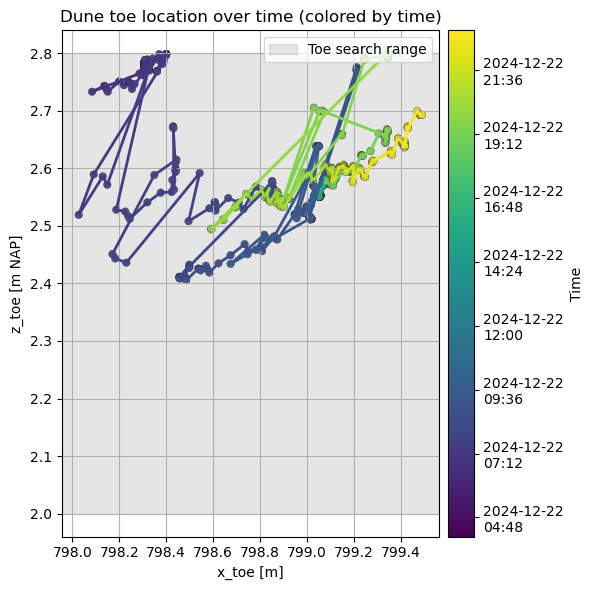

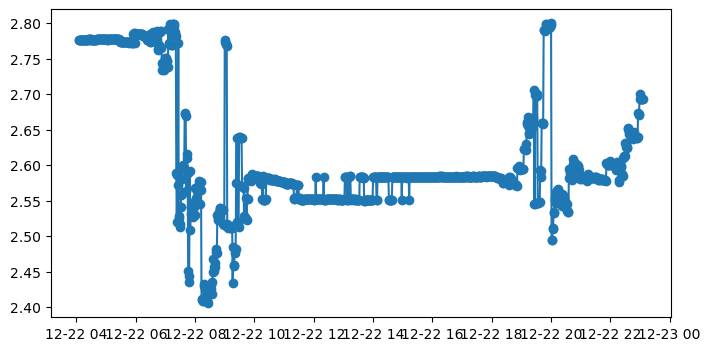

In [8]:
# Plot toe location evolution over time ------------
t1 = pd.Timestamp('22-12-2024 04:30') # was 2:00
t2 = pd.Timestamp('22-12-2024 22:00') # was 19dec 22:00
#t1 = pd.Timestamp('19-12-2024 02:30') # was 2:00
#t2 = pd.Timestamp('19-12-2024 23:00') # was 19dec 22:00
ds_plot = ds_profiles99_10min#.sel(minute=slice(t1,t2))

fig, ax = plt.subplots(figsize=(6, 6))

# Get toe coordinates and times
x_toe = ds_plot.x_toe.values
z_toe = ds_plot.z_toe.values
# use the datetime coordinate from the dataset
times = pd.to_datetime(ds_plot.minute.values)

# Mask out invalid entries
valid = ~(np.isnan(x_toe) | np.isnan(z_toe))
if valid.sum() == 0:
    raise RuntimeError('No valid toe points to plot')

x_toe = x_toe[valid]
z_toe = z_toe[valid]
times = times[valid]

# Map datetimes to numeric for colormap scaling
time_nums = mdates.date2num(times)
norm = mcolors.Normalize(vmin=time_nums.min(), vmax=time_nums.max())

# Plot colored line using LineCollection so color varies with time
from matplotlib.collections import LineCollection
points = np.array([x_toe, z_toe]).T
segments = np.concatenate([points[:-1, None, :], points[1:, None, :]], axis=1)
lc = LineCollection(segments, cmap='viridis', norm=norm)
# associate each segment with the time of its starting point
lc.set_array(time_nums[:-1])
lc.set_linewidth(2)
ax.add_collection(lc)

# Scatter points colored by time
sc = ax.scatter(x_toe, z_toe, c=time_nums, cmap='viridis', norm=norm, s=30, edgecolor='k', linewidth=0.2)

# Colorbar with readable datetime labels
cb = fig.colorbar(lc, ax=ax, pad=0.02)
# convert ticks to human-readable datetimes
tick_locs = cb.get_ticks()
tick_labels = [mdates.num2date(t).strftime('%Y-%m-%d\n%H:%M') for t in tick_locs]
cb.ax.set_yticklabels(tick_labels)
cb.set_label('Time')

# Highlight toe search range
ax.axhspan(z_min_toe, z_max_toe, alpha=0.2, color='gray', label=f'Toe search range')

ax.set_xlabel('x_toe [m]')
ax.set_ylabel('z_toe [m NAP]')
ax.set_title('Dune toe location over time (colored by time)')
ax.grid()
ax.legend(loc='upper right')

# autoscale view to include LineCollection
ax.autoscale()
plt.tight_layout()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(times, z_toe, '-o', label='z_toe')

In [9]:
## 4) Determine r50%, r90%, r99%, r_filtered based on 1min blocks
# Fast block-based approach (no rolling)
# Centered 1-minute blocks: 00:00:30–00:01:30 -> label 00:01:00
t_shift = pd.to_datetime(ds.t.values) + pd.Timedelta(seconds=30)
minute_labels = t_shift.floor("min")

r = ds.radius_lidar.assign_coords(minute=("t", minute_labels))

percentiles = [50, 90, 99]

def nanpercentile_q(a, q):
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=RuntimeWarning, message="All-NaN slice encountered")
        #return np.nanpercentile(a, q, axis=-1)
        return percentile_nans_lowest(a, q, axis=-1) 

r_percentiles = xr.apply_ufunc(
    nanpercentile_q,
    r.groupby("minute"),
    percentiles,
    input_core_dims=[["t"], ["q"]],
    output_core_dims=[["q"]],
    vectorize=True,
    dask="parallelized",
    output_dtypes=[float],
    keep_attrs=True
)

# dims: (minute, obs_number, q)
r_percentiles = r_percentiles.transpose("obs_number", "minute", "q")
r_percentiles = r_percentiles.assign_coords(q=percentiles)

# Crop to same time range as r99_10min, extract r50, r90, r99
r_percentiles = r_percentiles.sel(minute=slice(r99_10min.minute.values[0], r99_10min.minute.values[-1]))
r50 = r_percentiles.sel(q=50)
r90 = r_percentiles.sel(q=90)
r99 = r_percentiles.sel(q=99)

In [10]:
## 5) DETERMINE r_filtered: OUTLIER FILTERING
# 1) Use r90% where likely dry. Otherwise nan ----------------------------
cond1 = (r99 - r90) < 0.05  # if close, then both are dry. Use 90%
cond2 = (r90 - r50) < 0.05  # if 99% has a larger difference but 50% is close, than probably all dry, but slumping between 90% and 99%

r_filtered = r90.where(cond1 | cond2) # sets r_filtered = r90 where either condition is True, and NaN otherwise

# 2) Fill nans: temporal interpolation ----------------------------
# Interpolate temporally (along 'minute'), for given obs_number, if Δr<5cm between previous and next valid value.
r_temp = r_filtered.interpolate_na(dim="minute", method="linear", use_coordinate=False) # temporarily fill all nan gaps by linear interpolation

# Only keep interpolated values where gap between prev/next valid values is < 5cm
r_prev = r_filtered.ffill(dim="minute")
r_next = r_filtered.bfill(dim="minute")
r_filtered = r_temp.where(np.abs(r_prev - r_next) <= 0.05)

# 3) Fill nans: spatial interpolation ----------------------------
# Interpolate spatially (along 'obs_number'), for given minute, if Δr<5cm
r_temp = r_filtered.interpolate_na(dim="obs_number", method="linear", use_coordinate=False)

# Only keep interpolated values where gap between prev/next valid values (in spatial direction) is < 5cm
r_prev = r_filtered.ffill(dim="obs_number")
r_next = r_filtered.bfill(dim="obs_number")
r_filtered = r_temp.where(np.abs(r_prev - r_next) <= 0.05)

# 4) Fill remaining nans: use r99_10min
r_final = r_filtered.fillna(r99_10min)

# 5) Save result to Xarray Dataset
# Define a new ds_profiles: a copy of ds, without the coordinate t, and with r_final as radius_lidar
ds_profiles = ds.drop_dims("t")        # drops t dimension and its coordinate from ds
ds_profiles['radius_lidar'] = r_final  # Assign r_final as the new radius_lidar

ds_profiles = convert_lidar_coordinates_ds(ds_profiles, 'local', max_echos=False, keep_I=False, keep_r=True, keep_y=False) 

C:\Users\dpoppema\AppData\Local\Temp\ipykernel_15712\3082619710.py:60: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


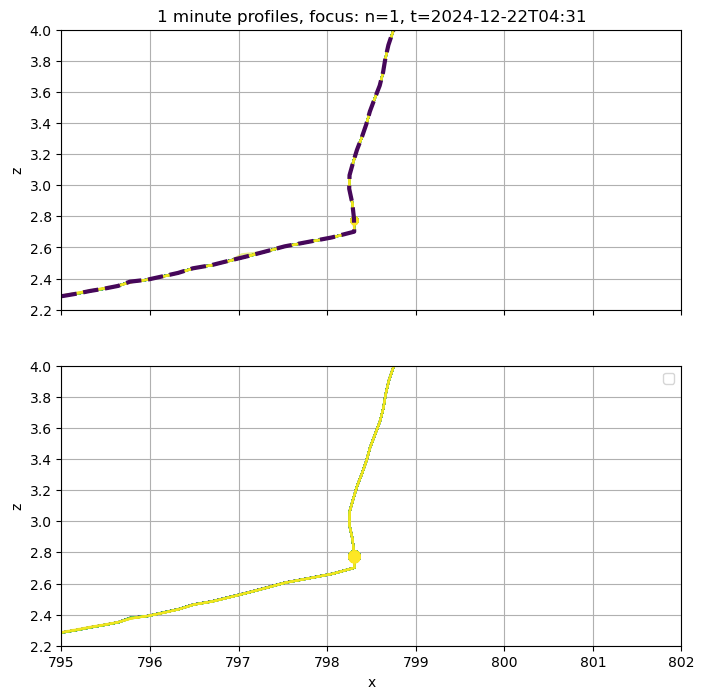

In [12]:
# PLOT 1-MIN PROFILES AND 10-MIN 99% PROFILES, WITH TOE LOCATION
# SWITHC COMMENTS FOR PLOTTING 1-MIN PROFILES, PLUS FOCUS PLOT FOR PREVIOUS-CURRENT-NEXT PROFILE
#t1 = pd.Timestamp('19-12-2024 18:00') # was 2:00
#t2 = pd.Timestamp('19-12-2024 19:00') # was 19dec 22:00
t1 = pd.Timestamp('22-12-2024 04:30') # was 2:00
t2 = pd.Timestamp('22-12-2024 05:30') # was 19dec 22:00
#t1 = np.datetime64('2025-01-01T12:00')
#t2 = np.datetime64('2025-01-02T09:09')  # ensure that Jan 2 is selected, not Feb 1
#t1 =  t1 + pd.Timedelta(minutes=60)  
#t2 =  t2 + pd.Timedelta(minutes=60)

n_plot = 60#len(minutes)
n_focus = 1#n_focus + 1  # 3, 24

x = ds_profiles.sel(minute=slice(t1,t2)).x  # dims: (obs_number, minute)
z = ds_profiles.sel(minute=slice(t1,t2)).z  # dims: (obs_number, minute)
x_toe = ds_profiles99_10min.sel(minute=slice(t1,t2)).x_toe  # dims: (minute,)
z_toe = ds_profiles99_10min.sel(minute=slice(t1,t2)).z_toe  # dims: (minute,)

minutes = ds_profiles.sel(minute=slice(t1,t2)).minute.values
t_focus = minutes[n_focus]

n_profiles = np.min([len(minutes), n_plot])
cmap = plt.get_cmap('viridis')  # or 'plasma', 'inferno', etc.
colors = cmap(np.linspace(0, 1, n_profiles))

fig, axs = plt.subplots(2, 1, figsize=(8, 8), sharex=True, sharey=True)
ax = axs[0]
for i, color in enumerate(colors):
    ax.plot(x_toe[i], z_toe[i], 'o', color=color, markersize=5)
    if i != n_focus:
        ax.plot(x[:, i], z[:, i], '-', color=color, alpha=0.5)
for i, color in enumerate(colors):
    if i == n_focus:
        ax.plot(x[:, i], z[:, i], '--', color=color, linewidth=3)

ax.set_ylabel('z')
ax.set_title('1 minute profiles, t={}'.format(np.datetime_as_string(t_focus, unit='m')))
ax.set_title( '1 minute profiles, focus: n={}'.format(n_focus) + ', t={}'.format(np.datetime_as_string(t_focus, unit='m')))
ax.grid()

ax = axs[1]

# ax.plot(x[:, n_focus], z[:, n_focus], '--', color='black', linewidth=2, label='Focused profile')
# if n_focus > 0:
#     ax.plot(x[:, n_focus-1], z[:, n_focus-1], '--', color='blue', linewidth=1, label='Previous')
# if n_focus < n_profiles:
#     ax.plot(x[:, n_focus+1], z[:, n_focus+1], '--', color='red', linewidth=1, label='next')

x = ds_profiles99_10min.sel(minute=slice(t1,t2)).x  # dims: (obs_number, minute)
z = ds_profiles99_10min.sel(minute=slice(t1,t2)).z  # dims: (obs_number, minute)
for i, color in enumerate(colors):
    ax.plot(x_toe[i], z_toe[i], 'o', color=color, markersize=8)
    ax.plot(x[:, i], z[:, i], '-', color=color, alpha=0.5)  

ax.set_xlabel('x')
ax.set_ylabel('z')
ax.set_xlim([795, 802])
ax.set_ylim([2.2, 4.0])
ax.legend()
ax.grid()

In [13]:
# Determine dune volume in cliff
x = ds_profiles.x  # dims: (obs_number, minute)
z = ds_profiles.z  # dims: (obs_number, minute)

# t1 = pd.Timestamp('19-12-2024 8:27') # was 2:00
# t2 = pd.Timestamp('19-12-2024 8:28') # was 19dec 22:00
# x = ds_profiles.sel(minute=slice(t1,t2)).x  # dims: (obs_number, minute)
# z = ds_profiles.sel(minute=slice(t1,t2)).z  # dims: (obs_number, minute)

# Settings ---------------------------------------------------------------------------------------    
z_min = 3.5
z_max = 4.5
x_right = 810.0

areas = []
erosion_volumes =[]
minutes_area = []

def polygon_area(x_coords, z_coords):
    """Calculate polygon area using shoelace formula"""
    return 0.5 * np.abs(np.dot(x_coords, np.roll(z_coords, 1)) - 
                        np.dot(z_coords, np.roll(x_coords, 1)))

def linear_interp(z1, x1, z2, x2, z_target):
    """Linear interpolation: find x at target z"""
    if z2 == z1:
        return None
    return x1 + (x2 - x1) * (z_target - z1) / (z2 - z1)

def find_polygon_area_for_profile(x_t, z_t, z_min, z_max, x_right, minute):
    "Calculate the area of the polygon formed by the profile between z_min and z_max, and the vertical line at x_right. minute is only used for error messages, not for calculation."

        # Skip fully NaN profiles
    if np.all(np.isnan(x_t)) or np.all(np.isnan(z_t)):
        return np.nan
    
    # Warning on remaining NaNs
    if np.any(np.isnan(x_t)) or np.any(np.isnan(z_t)):
        warnings.warn(f"NaN values found in profile at minute {minute}.")
        #raise ValueError(f"NaN values found in profile at minute {minute}")
    
    # Find points in elevation range [z_min, z_max]
    in_range_mask = (z_t >= z_min) & (z_t <= z_max)
    
    if not np.any(in_range_mask):
        raise ValueError(f"No data in range [z_min={z_min}, z_max={z_max}] for profile at minute {minute}")
    
    # Get indices of points in range
    in_range_idx = np.where(in_range_mask)[0]
    first_idx = in_range_idx[0]
    last_idx = in_range_idx[-1]
    
    # Initialize polygon with points in range
    x_poly = list(x_t[first_idx:last_idx+1])
    z_poly = list(z_t[first_idx:last_idx+1])
    
    # Interpolate at z_max on the right (if last point is below z_max)
    if z_poly[-1] < z_max and last_idx < len(z_t) - 1:
        x_at_zmax = linear_interp(z_t[last_idx], x_t[last_idx],
                                  z_t[last_idx+1], x_t[last_idx+1], z_max)
        if x_at_zmax is not None:
            x_poly.append(x_at_zmax)
            z_poly.append(z_max)
    
    # Add right boundary corners: (810, z_max) and (810, z_min)
    x_poly.append(x_right)
    z_poly.append(z_max)
    
    x_poly.append(x_right)
    z_poly.append(z_min)
    
    # Interpolate at z_min on the left (if first point is above z_min)
    if z_poly[0] > z_min and first_idx > 0:
        x_at_zmin = linear_interp(z_t[first_idx-1], x_t[first_idx-1],
                                  z_t[first_idx], x_t[first_idx], z_min)
        if x_at_zmin is not None:
            x_poly.append(x_at_zmin)
            z_poly.append(z_min)
    
    # Convert to numpy arrays
    x_poly = np.array(x_poly)
    z_poly = np.array(z_poly)
    
    # Calculate area
    area = polygon_area(x_poly, z_poly)
    return area


#fig, ax = plt.subplots(figsize=(12, 6))

# Calculate dune area: loop over each time step ------------------------------------------------
for t_idx, minute in enumerate(z.minute.values):
    x_t = x.values[:, t_idx]
    z_t = z.values[:, t_idx]
    z_toe = ds_profiles99_10min.z_toe.values[t_idx]
    #z_min = z_toe + 0.5


    area = find_polygon_area_for_profile(x_t, z_t, z_min, z_max, x_right, minute)
    areas.append(area)
    minutes_area.append(minute)

    # Calculate area of previous time step
    # Use same z_min as for previous time step, to be consistent in area calculation and erosion estimation
    if t_idx == 0:
        erosion = np.nan
    else:
        x_prev = x.values[:, t_idx-1]
        z_prev = z.values[:, t_idx-1]
        area_prev = find_polygon_area_for_profile(x_prev, z_prev, z_min, z_max, x_right, minute)
        erosion = - ( area - area_prev )
    erosion_volumes.append(erosion)
    # ax.plot(x_poly,z_poly,'-x')

# Check results
if len(areas) == 0:
    raise ValueError("No valid profiles found for area calculation")

# Create DataArray
area_cliff = xr.DataArray(
    areas,
    dims="minute",
    coords={"minute": minutes_area},
    name="cliff_area_m2"
)

cliff_erosion = xr.DataArray(
    erosion_volumes,
    dims="minute",
    coords={"minute": minutes_area},
    name="cliff_erosion_m2"
)

print(f"Successfully calculated cliff erosion for {len(areas)} time steps")

#cliff_erosion = - area_cliff.diff(dim="minute") 
#cliff_erosion = cliff_erosion.reindex(minute=x.minute)

Successfully calculated cliff erosion for 1141 time steps


Text(0.5, 1.0, 'Dune volume between z_toe+0.5 and 4.5 NAP')

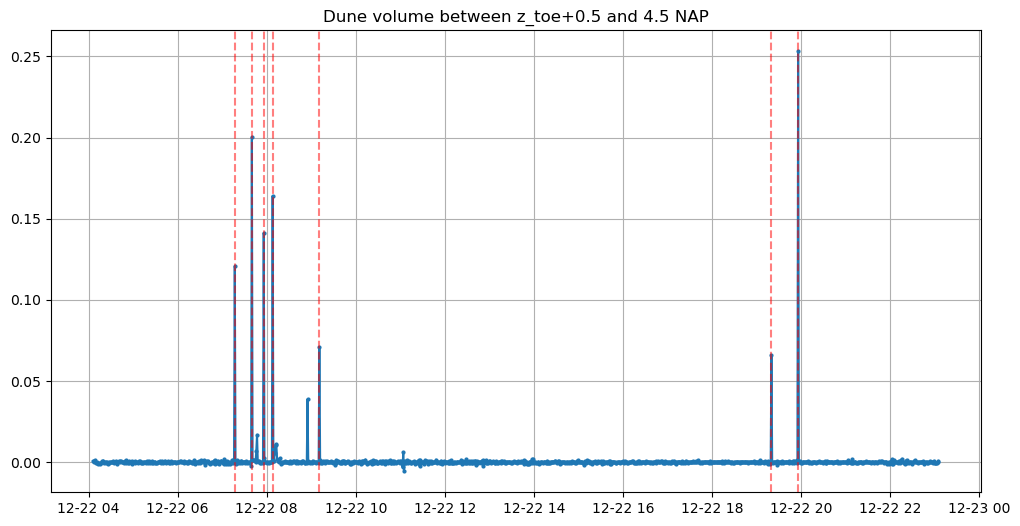

In [14]:
# Plot cliff erosion based on z_min=z_toe+0.5
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(cliff_erosion.minute,erosion_volumes, '-o', markersize=2)
# plot a vertical line at every time step where cliff_erosion > 0.05
for t, erosion in zip(cliff_erosion.minute.values, cliff_erosion.values):
    if erosion > 0.04:
        ax.axvline(t, color='red', linestyle='--', alpha=0.5)
ax.grid()
ax.set_title('Dune volume between z_toe+0.5 and 4.5 NAP')

Text(0.5, 1.0, 'Dune volume between 3 and 4.5 NAP')

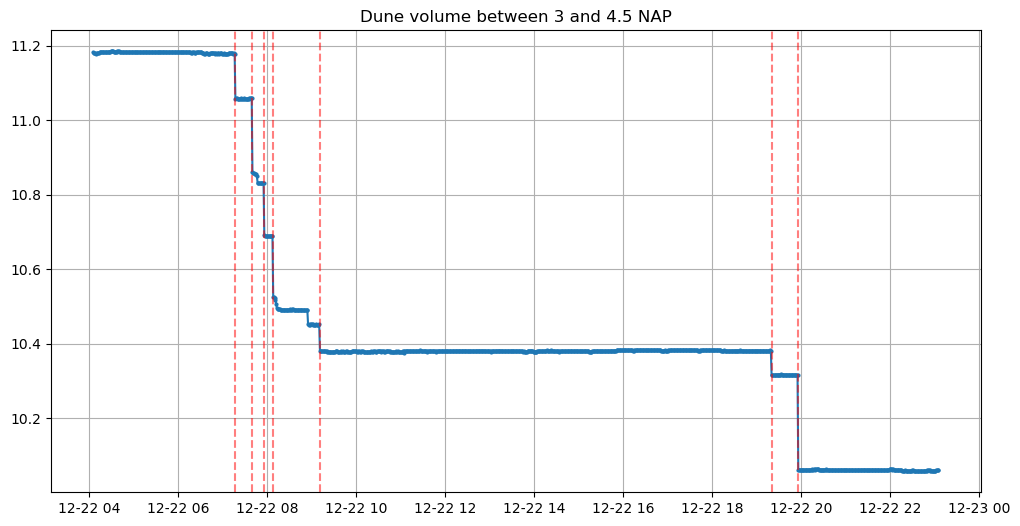

In [15]:
# Plot cliff erosion based on z_min=3
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(x.minute,area_cliff, '-o', markersize=2)
# plot a vertical line at every time step where cliff_erosion > 0.05
for t, erosion in zip(cliff_erosion.minute.values, cliff_erosion.values):
    if erosion > 0.05:
        ax.axvline(t, color='red', linestyle='--', alpha=0.5)
ax.grid()
ax.set_title('Dune volume between 3 and 4.5 NAP')

C:\Users\dpoppema\AppData\Local\Temp\ipykernel_15712\226690693.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  cb.ax.set_yticklabels(tick_labels)


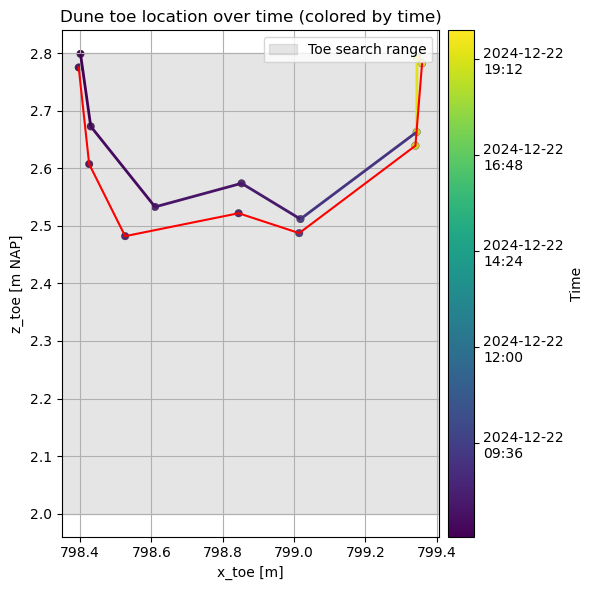

In [22]:
# PLOT DUNE TOE AT MOMENT OF SLUMPING

# Plot toe location evolution over time ------------
t1 = pd.Timestamp('22-12-2024 04:30') # was 2:00
t2 = pd.Timestamp('22-12-2024 22:00') # was 19dec 22:00
#t1 = pd.Timestamp('19-12-2024 02:30') # was 2:00
#t2 = pd.Timestamp('19-12-2024 23:00') # was 19dec 22:00
ds_plot = ds_profiles99_10min.sel(minute=slice(t1,t2))

fig, ax = plt.subplots(figsize=(6, 6))

# Get toe coordinates and times
x_toe = ds_plot.x_toe.values
z_toe = ds_plot.z_toe.values
times = pd.to_datetime(ds_plot.minute.values)

x_toe = x_toe_slumping_approx.values
z_toe = z_toe_slumping_approx.values
times = pd.to_datetime(x_toe_slumping_approx.minute.values)

# Mask out invalid entries
valid = ~(np.isnan(x_toe) | np.isnan(z_toe) )
if valid.sum() == 0:
    raise RuntimeError('No valid toe points to plot')

x_toe = x_toe[valid]
z_toe = z_toe[valid]
times = times[valid]

# Map datetimes to numeric for colormap scaling
time_nums = mdates.date2num(times)
norm = mcolors.Normalize(vmin=time_nums.min(), vmax=time_nums.max())

# Plot colored line using LineCollection so color varies with time
from matplotlib.collections import LineCollection
points = np.array([x_toe, z_toe]).T
segments = np.concatenate([points[:-1, None, :], points[1:, None, :]], axis=1)
lc = LineCollection(segments, cmap='viridis', norm=norm)
# associate each segment with the time of its starting point
lc.set_array(time_nums[:-1])
lc.set_linewidth(2)
ax.add_collection(lc)

# Scatter points colored by time
sc = ax.scatter(x_toe, z_toe, c=time_nums, cmap='viridis', norm=norm, s=30, edgecolor='k', linewidth=0.2)
sc = ax.scatter(x_toe_fine, z_toe_fine, c=time_nums, cmap='viridis', norm=norm, s=30, edgecolor='k', linewidth=0.2)
ax.plot(x_toe_fine, z_toe_fine, '-', color='red')

# Colorbar with readable datetime labels
cb = fig.colorbar(lc, ax=ax, pad=0.02)
# convert ticks to human-readable datetimes
tick_locs = cb.get_ticks()
tick_labels = [mdates.num2date(t).strftime('%Y-%m-%d\n%H:%M') for t in tick_locs]
cb.ax.set_yticklabels(tick_labels)
cb.set_label('Time')

# Highlight toe search range
ax.axhspan(z_min_toe, z_max_toe, alpha=0.2, color='gray', label=f'Toe search range')

ax.set_xlabel('x_toe [m]')
ax.set_ylabel('z_toe [m NAP]')
ax.set_title('Dune toe location over time (colored by time)')
ax.grid()
ax.legend(loc='upper right')

# autoscale view to include LineCollection
ax.autoscale()
plt.tight_layout()

In [18]:
# CORRECT DUNE PROFILES FOR INSTANCES WITH CLIFF EROSION: AVG OF PREVIOUS AND NEXT
ds_profiles_corrected = ds_profiles.copy().drop_vars(['x', 'z'])

# where cliff erosion is > 0.04 m2, replace profile(t) with avg of profile(t-1) and profile(t+1)
for i in range(1, len(cliff_erosion)-1):
    if cliff_erosion.values[i] > 0.04:
        ds_profiles_corrected['radius_lidar'][:, i] = 0.5 * (ds_profiles.radius_lidar[:, i-1] + ds_profiles.radius_lidar[:, i+1])

# Convert to x,z again
ds_profiles_corrected = convert_lidar_coordinates_ds(ds_profiles_corrected, 'local', max_echos=False, keep_I=False, keep_r=True, keep_y=False) # skip intensity. Max echos already taken, not needed again

# TO DO: METHOD THAT WORKS FOR MULTIPLE CONSECUTIVE TIME STEPS WITH CLIFF EROSION

In [19]:
# CORRECT DUNE PROFILES FOR FOAM AND WAVES
ds_profiles_corrected2 = ds_profiles_corrected.copy().drop_vars(['x', 'z'])
dr = r99_10min - ds_profiles_corrected.radius_lidar
mask_dr = dr > 0.05      # ~ Instantaneous profile is more than 5 cm "above" 10min profile. Not exactly, r instead of z
mask_x_toe = ds_profiles_corrected.x < (ds_profiles99_10min.x_toe - 1 ) # Point more than 1 m seaward of toe location. 
mask = mask_dr & mask_x_toe # replace where mask is true

# Keep ds_profiles_corrected where mask is False, replace by r99_10min where mask is True
ds_profiles_corrected2['radius_lidar'] = ds_profiles_corrected2['radius_lidar'].where(~mask, r99_10min)
ds_profiles_corrected2 = convert_lidar_coordinates_ds(ds_profiles_corrected2, 'local', max_echos=False, keep_I=False, keep_r=True, keep_y=False) #add x, z back

Text(0.5, 1.0, 'Instances where profile was corrected based on r99_10min')

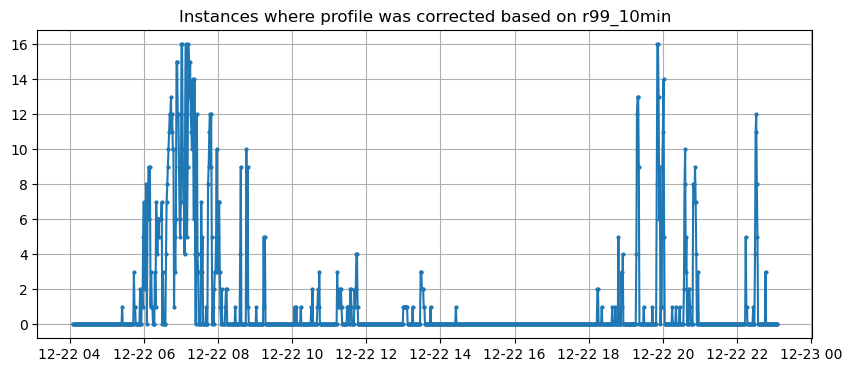

In [20]:
# Plot correction instances

mask_timeseries = mask.sum(dim="obs_number")  # True for minutes where at least one obs_number is masked

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(ds_profiles_corrected2.minute.values, mask_timeseries.values, '-o', markersize=2)
ax.grid()
ax.set_title('Instances where profile was corrected based on r99_10min')

Text(0.5, 1.0, 'Profiles 1 minute before slumping')

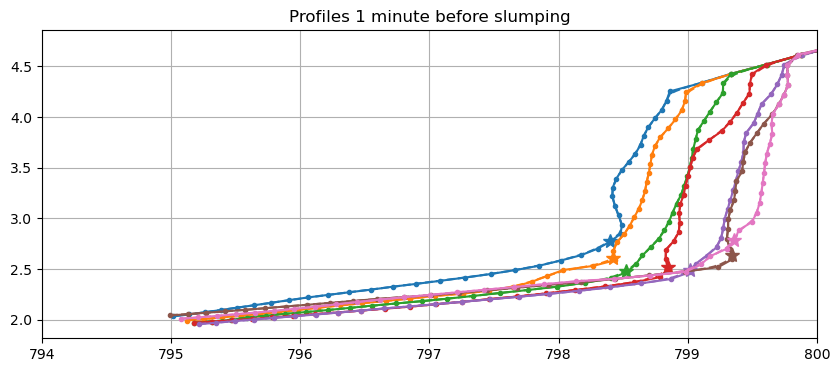

In [23]:
# Calculate toe at moment (minute) before slumping, based on smoothed and unsmoothed profiles, and compare
t_slumping = cliff_erosion.minute.values[cliff_erosion.values > 0.04]
t_before_slumping = t_slumping - np.timedelta64(1, 'm')  # 1 minute before slumping

x_toe_slumping_approx = ds_profiles99_10min.x_toe.sel(minute=t_before_slumping, method='nearest')
z_toe_slumping_approx = ds_profiles99_10min.z_toe.sel(minute=t_before_slumping, method='nearest')

#x_toe_fine, z_toe_fine = extract_toe_curvature(, ds_profiles_corrected.z, dl_target, dl_smoothing, z_min_toe, z_max_toe)

# determine x_toe and z_toe at the time steps before slumping
x = ds_profiles_corrected.x.sel(minute=t_before_slumping, method='nearest')
z = ds_profiles_corrected.z.sel(minute=t_before_slumping, method='nearest')

n_minutes = x.shape[1]
x_toe_fine = np.full(n_minutes, np.nan)
z_toe_fine = np.full(n_minutes, np.nan)

fig, ax = plt.subplots(figsize=(10, 4))

# Loop over every profile and resample it to find the curvature peak inside the target elevation range
for minute_idx in range(n_minutes):
    color = mpl.colormaps['tab10'](minute_idx)

    # Resample and smooth the profile for this minute, and extract the toe based on curvature    
    toe = extract_toe_curvature(x[:, minute_idx], z[:, minute_idx], dl_target, 0.1, z_min_toe, z_max_toe)
    if toe is None:
        continue
    
    x_toe_fine[minute_idx], z_toe_fine[minute_idx], x_interp, z_interp, *_ = toe

    # Add profile and toe to plot
    ax.plot(x[:, minute_idx], z[:, minute_idx], '-o', markersize=3, color=color) # profile
    ax.plot(x_interp, z_interp, '--', markersize=3, color=color)                 # smoothed profile

    ax.plot(x_toe_fine[minute_idx], z_toe_fine[minute_idx], '*', color=color, markersize=10, label='Toe')  # toe

    #x_toe[minute_idx], z_toe[minute_idx], x_interp, z_interp, curvature_profile, curvature_in_range, curvature_max[minute_idx] = toe
ax.set_xlim([794, 800])
ax.grid()
ax.set_title('Profiles 1 minute before slumping')

# TO DO: MAKE PROFILES UNIQUE WRT X.

Text(0.5, 1.0, 'Profiles 1 minute after slumping')

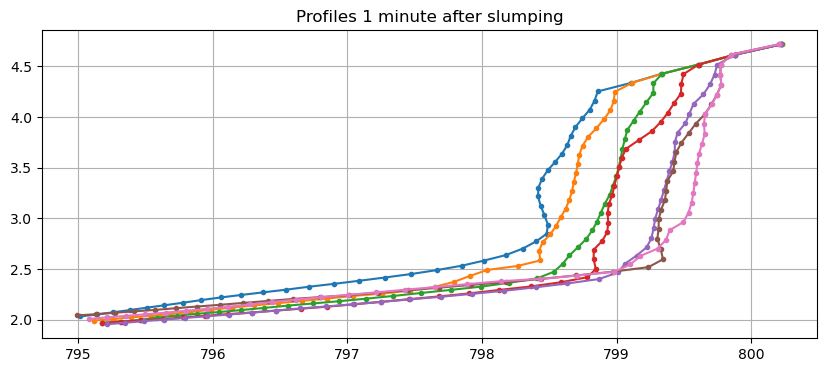

In [24]:
# Calculate toe at moment (minute) after slumping, based on smoothed and unsmoothed profiles, and compare
t_slumping = cliff_erosion.minute.values[cliff_erosion.values > 0.04]
t_after_slumping = t_slumping + np.timedelta64(1, 'm')  # 1 minute before slumping

x_toe_slumping_approx = ds_profiles99_10min.x_toe.sel(minute=t_after_slumping, method='nearest')
z_toe_slumping_approx = ds_profiles99_10min.z_toe.sel(minute=t_after_slumping, method='nearest')

#x_toe_fine, z_toe_fine = extract_toe_curvature(, ds_profiles_corrected.z, dl_target, dl_smoothing, z_min_toe, z_max_toe)

# determine x_toe and z_toe at the time steps before slumping
x = ds_profiles_corrected.x.sel(minute=t_before_slumping, method='nearest')
z = ds_profiles_corrected.z.sel(minute=t_before_slumping, method='nearest')

n_minutes = x.shape[1]
x_toe_fine = np.full(n_minutes, np.nan)
z_toe_fine = np.full(n_minutes, np.nan)

fig, ax = plt.subplots(figsize=(10, 4))
# Loop over every profile and resample it to find the curvature peak inside the target elevation range
for minute_idx in range(n_minutes):
    # Resample and smooth the profile for this minute, and extract the toe based on curvature    
    toe = extract_toe_curvature(x[:, minute_idx], z[:, minute_idx], dl_target, dl_smoothing, z_min_toe, z_max_toe)
    if toe is None:
        continue
    
    x_toe_fine[minute_idx], z_toe_fine[minute_idx], x_interp, z_interp, *_ = toe

    ax.plot(x[:, minute_idx], z[:, minute_idx], '-o', markersize=3)
    #ax.plot(x_interp, z_interp, '-', markersize=3)

    #ax.plot(x_toe_fine[minute_idx], z_toe_fine[minute_idx], 'r*', markersize=10, label='Toe')

    #x_toe[minute_idx], z_toe[minute_idx], x_interp, z_interp, curvature_profile, curvature_in_range, curvature_max[minute_idx] = toe
ax.grid()
ax.set_title('Profiles 1 minute after slumping')

C:\Users\dpoppema\AppData\Local\Temp\ipykernel_15712\2123537493.py:75: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


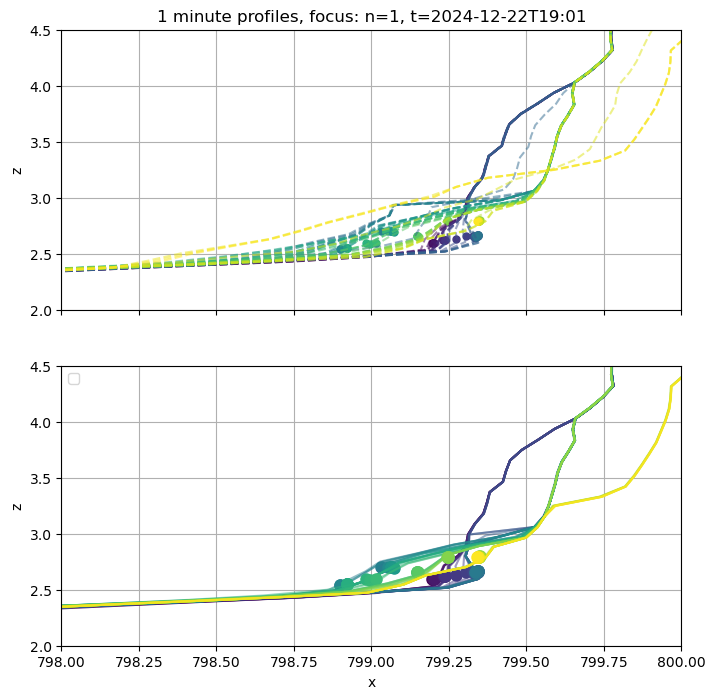

In [26]:
# PLOT 1-MIN PROFILES AND 10-MIN 99% PROFILES, WITH TOE LOCATION

# # define mask_plot: true where mask is true, or neighbouring points over dim obs_number are true
# mask_plot = mask.copy()
# for i in range(1, mask.shape[0]-1):
#     mask_plot[i, :] = mask_plot[i, :] | mask[i-1, :] | mask[i+1, :]

# SWITHC COMMENTS FOR PLOTTING 1-MIN PROFILES, PLUS FOCUS PLOT FOR PREVIOUS-CURRENT-NEXT PROFILE
t1 = pd.Timestamp('22-12-2024 19:00') # was 2:00
t2 = pd.Timestamp('22-12-2024 20:30') # was 19dec 22:00
#t1 = pd.Timestamp('19-12-2024 17:30') # was 2:00
#t2 = pd.Timestamp('19-12-2024 19:00') # was 19dec 22:00
#t1 = np.datetime64('2025-01-01T12:00')
#t2 = np.datetime64('2025-01-02T09:09')  # ensure that Jan 2 is selected, not Feb 1
#t1 =  t1 + pd.Timedelta(minutes=60)  
#t2 =  t2 + pd.Timedelta(minutes=60)

n_plot = 60#len(minutes)
n_focus = 1#n_focus + 1  # 3, 24

x = ds_profiles_corrected.sel(minute=slice(t1,t2)).x  # dims: (obs_number, minute)
z = ds_profiles_corrected.sel(minute=slice(t1,t2)).z  # dims: (obs_number, minute)
x2 = ds_profiles_corrected2.sel(minute=slice(t1,t2)).x  # dims: (obs_number, minute)
z2 = ds_profiles_corrected2.sel(minute=slice(t1,t2)).z.where(mask)  # dims: (obs_number, minute)
x_toe = ds_profiles99_10min.sel(minute=slice(t1,t2)).x_toe  # dims: (minute,)
z_toe = ds_profiles99_10min.sel(minute=slice(t1,t2)).z_toe  # dims: (minute,)

minutes = ds_profiles_corrected.sel(minute=slice(t1,t2)).minute.values
t_focus = minutes[n_focus]

n_profiles = np.min([len(minutes), n_plot])
cmap = plt.get_cmap('viridis')  # or 'plasma', 'inferno', etc.
colors = cmap(np.linspace(0, 1, n_profiles))

fig, axs = plt.subplots(2, 1, figsize=(8, 8), sharex=True, sharey=True)
ax = axs[0]
# for i, color in enumerate(colors):
#     ax.plot(x_toe[i], z_toe[i], 'o', color=color, markersize=5)
#     if i != n_focus:
#         ax.plot(x[:, i], z[:, i], '-', color=color, alpha=0.5)
# for i, color in enumerate(colors):
#     if i == n_focus:
#         ax.plot(x[:, i], z[:, i], '--', color=color, linewidth=3)
for i, color in enumerate(colors):
    ax.plot(x_toe[i], z_toe[i], 'o', color=color, markersize=5)
    #ax.plot(x2[:, i], z2[:, i], '-', color=color, linewidth=3)
    ax.plot(x2[:, i], z2[:, i], '-', color=color, alpha=0.5, linewidth=3)

for i, color in enumerate(colors):
    ax.plot(x[:, i], z[:, i], '--', color=color, alpha=0.5)

ax.set_ylabel('z')
ax.set_title('1 minute profiles, t={}'.format(np.datetime_as_string(t_focus, unit='m')))
ax.set_title( '1 minute profiles, focus: n={}'.format(n_focus) + ', t={}'.format(np.datetime_as_string(t_focus, unit='m')))
ax.grid()

ax = axs[1]

# ax.plot(x[:, n_focus], z[:, n_focus], '--', color='black', linewidth=2, label='Focused profile')
# if n_focus > 0:
#     ax.plot(x[:, n_focus-1], z[:, n_focus-1], '--', color='blue', linewidth=1, label='Previous')
# if n_focus < n_profiles:
#     ax.plot(x[:, n_focus+1], z[:, n_focus+1], '--', color='red', linewidth=1, label='next')

x = ds_profiles99_10min.sel(minute=slice(t1,t2)).x  # dims: (obs_number, minute)
z = ds_profiles99_10min.sel(minute=slice(t1,t2)).z  # dims: (obs_number, minute)
for i, color in enumerate(colors):
    ax.plot(x_toe[i], z_toe[i], 'o', color=color, markersize=8)
    ax.plot(x[:, i], z[:, i], '-', color=color, alpha=0.5)  

ax.set_xlabel('x')
ax.set_ylabel('z')
ax.set_xlim([798, 800])
ax.set_ylim([2.0, 4.5])
ax.legend()
ax.grid()    

In [28]:
# Determine dune volume, full dune
#x = ds_profiles.x  # dims: (obs_number, minute)
#z = ds_profiles.z  # dims: (obs_number, minute)
x = ds_profiles_corrected.x  # dims: (obs_number, minute)
z = ds_profiles_corrected.z  # dims: (obs_number, minute)

# t1 = pd.Timestamp('19-12-2024 04:27') # was 2:00
# t2 = pd.Timestamp('19-12-2024 04:28') # was 19dec 22:00
# x = ds_profiles.sel(minute=slice(t1,t2)).x  # dims: (obs_number, minute)
# z = ds_profiles.sel(minute=slice(t1,t2)).z  # dims: (obs_number, minute)
#fig, ax = plt.subplots(figsize=(12, 6))

def polygon_area(x_coords, z_coords):
    """Calculate polygon area using shoelace formula"""
    return 0.5 * np.abs(np.dot(x_coords, np.roll(z_coords, 1)) - 
                        np.dot(z_coords, np.roll(x_coords, 1)))

def linear_interp_x(x1, z1, x2, z2, x_target):
    """Linear interpolation: find z at target x"""
    if x2 == x1:
        return None
    return z1 + (z2 - z1) * (x_target - x1) / (x2 - x1)

def linear_interp_z(z1, x1, z2, x2, z_target):
    """Linear interpolation: find x at target z"""
    if z2 == z1:
        return None
    return x1 + (x2 - x1) * (z_target - z1) / (z2 - z1)
if n_storm == 1:
    x_min = 792.0
elif n_storm ==2:
    x_min = 796.0
elif n_storm == 3:
    x_min = 796.0
else:
    raise KeyError('n_storm must be 1, 2 or 3')
z_max = 4.5
x_right = 810.0

areas = []
minutes_valid = []

# Loop over each time step
for t_idx, minute in enumerate(z.minute.values):
    x_t = x.values[:, t_idx]
    z_t = z.values[:, t_idx]
    
    # Skip fully NaN profiles
    if np.all(np.isnan(x_t)) or np.all(np.isnan(z_t)):
        continue
    
    # Warning on remaining NaNs
    if np.any(np.isnan(x_t)) or np.any(np.isnan(z_t)):
        warnings.warn(f"NaN values found in profile at minute {minute}.")
        #raise ValueError(f"NaN values found in profile at minute {minute}")
    
    # Find points in elevation range of x_min and z_max
    in_range_mask = (x_t >= x_min) & (z_t <= z_max)
    
    if not np.any(in_range_mask):
        raise ValueError(f"No data in range [x_min={x_min}, z_max={z_max}] for profile at minute {minute}")
    
    # Get indices of points in range
    in_range_idx = np.where(in_range_mask)[0]
    first_idx = in_range_idx[0]
    last_idx = in_range_idx[-1]
    
    # Initialize polygon with points in range
    x_poly = list(x_t[first_idx:last_idx+1])
    z_poly = list(z_t[first_idx:last_idx+1])
    
    # Interpolate at z_max on the right (if last point is below z_max)
    if z_poly[-1] < z_max and last_idx < len(z_t) - 1:
        x_at_zmax = linear_interp_z(z_t[last_idx], x_t[last_idx],
                                  z_t[last_idx+1], x_t[last_idx+1], z_max)
        if x_at_zmax is not None:
            x_poly.append(x_at_zmax)
            z_poly.append(z_max)
    
    # Add right boundary corners: (810, z_max) and (810, 1.0)
    x_poly.append(x_right)
    z_poly.append(z_max)
    
    x_poly.append(x_right)
    z_poly.append(1.0)

    x_poly.append(x_min) # point at x_min, z=1.5m
    z_poly.append(1.0)
    
    # Interpolate at x_min on the left (if first point is right of x_min)
    if x_poly[0] > x_min and first_idx > 0:
        z_at_xmin = linear_interp_x(x_t[first_idx-1], z_t[first_idx-1],
                                    x_t[first_idx], z_t[first_idx], x_min)
        if z_at_xmin is not None:
            x_poly.append(x_min)
            z_poly.append(z_at_xmin)

    # Convert to numpy arrays
    x_poly = np.array(x_poly)
    z_poly = np.array(z_poly)
    
    # Calculate area
    area = polygon_area(x_poly, z_poly)
    areas.append(area)
    minutes_valid.append(minute)

    # ax.plot(x_poly,z_poly,'-x')

# Check results
if len(areas) == 0:
    raise ValueError("No valid profiles found for area calculation")

# Create DataArray
#area_dune = xr.DataArray(
area_dune_corr = xr.DataArray(    
    areas,
    dims="minute",
    coords={"minute": minutes_valid},
    name="dune_area_m2"
)

ds_profiles_corrected['dune_area'] = area_dune_corr  # Assign area_dune_corr as the new dune_area variable


In [29]:
# Assign x_toe and z_toe to ds_profiles_corrected. Interpolate between slumping events
# Assign x_toe and z_toe at sluming events
ds_profiles_corrected['x_toe'] = xr.DataArray(  x_toe_fine,
                                                dims="minute",
                                                coords={"minute": t_before_slumping},
                                                name="x_toe"  )

ds_profiles_corrected['z_toe'] = xr.DataArray(  z_toe_fine,
                                                dims="minute",
                                                coords={"minute": t_before_slumping},
                                                name="z_toe"  )

# Interpolate x_toe and z_toe for continuous time series of toe location
# interpolate linearly. fill leading nans with the first known value (bfill) and v.v. for trailing nans (ffill)
ds_profiles_corrected['x_toe'] = ( ds_profiles_corrected['x_toe'].interpolate_na(dim='minute',method='linear').bfill(dim='minute').ffill(dim='minute') )  
ds_profiles_corrected['z_toe'] = ( ds_profiles_corrected['z_toe'].interpolate_na(dim='minute',method='linear').bfill(dim='minute').ffill(dim='minute') )  

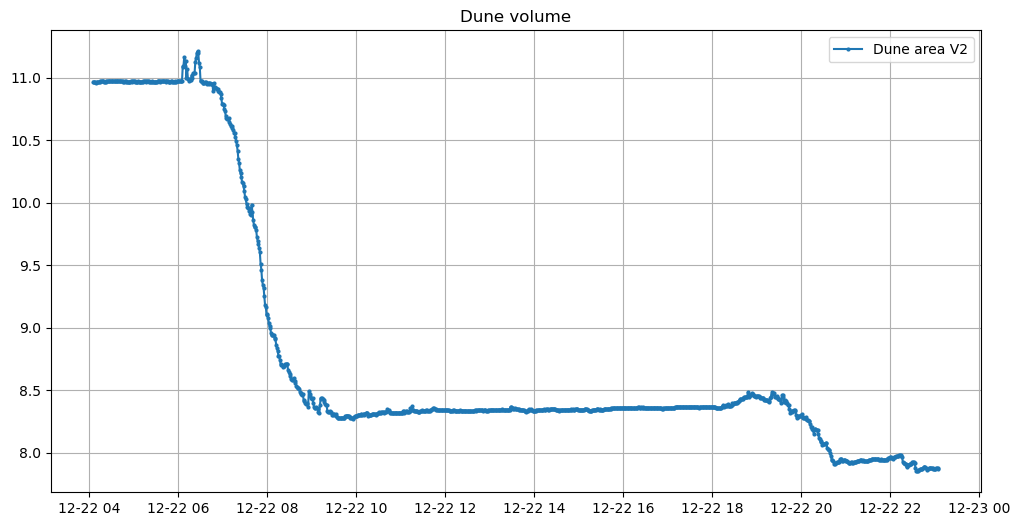

In [30]:
fig, ax = plt.subplots(figsize=(12, 6))
#ax.plot(x.minute, area_cliff, '-o', markersize=2, label='Cliff area (3-4.5m)')
#ax.plot(x.minute, area_dune-33 , '-o', markersize=2, label='Dune area')
ax.plot(x.minute, area_dune_corr-33 , '-o', markersize=2, label='Dune area V2')

ax.grid()
ax.set_title('Dune volume')
ax.legend()

t1 = pd.Timestamp('19-12-2024 04:00') # was 2:00
t2 = pd.Timestamp('19-12-2024 06:00') # was 19dec 22:00
#ax.set_xlim([t1, t2])
#ax.set_ylim([19,21])
#ax.set_ylim([17,20])

In [33]:
ds_profiles_corrected
ds_profiles_corrected['cliff_erosion'] = cliff_erosion
ds_profiles_corrected

<xarray.Dataset> Size: 663kB
Dimensions:                      (obs_number: 45, minute: 1141,
                                  rotation_matrix_rows: 3,
                                  rotation_matrix_cols: 3)
Coordinates:
  * obs_number                   (obs_number) int64 360B 0 1 2 3 ... 41 42 43 44
  * minute                       (minute) datetime64[ns] 9kB 2024-12-22T04:05...
    q                            int64 8B 90
Dimensions without coordinates: rotation_matrix_rows, rotation_matrix_cols
Data variables: (12/18)
    profile_angle                float32 4B ...
    beam_angle                   (obs_number) float64 360B 70.5 71.0 ... 92.5
    rotation_matrix_lidar_to_RD  (rotation_matrix_rows, rotation_matrix_cols) float64 72B ...
    z_i                          float64 8B 4.628
    x_i_RD                       float64 8B 7.248e+04
    y_i_RD                       float64 8B 4.521e+05
    ...                           ...
    x                            (obs_number, minute) float32 205kB 794.5 ......
    z                            (obs_number, minute) float32 205kB 2.233 ......
    x_toe                        (minute) float64 9kB 798.4 798.4 ... 799.4
    z_toe                        (minute) float64 9kB 2.793 2.793 ... 2.79 2.79
    dune_area                    (minute) float64 9kB 43.97 43.97 ... 40.87
    cliff_erosion                (minute) float64 9kB nan ... 0.0006385
Attributes: (12/14)
    name:                   storm2_lidar2_polar
    summary:                Hybrid Dune campaign, data of lidar 2 during storm 2
    instrument:             lidar 2
    period:                 storm 2, 2024-12-20 to 2024-12-23
    instrument type:        Sick Multiscan 165
    time zone:              UTC+1
    ...                     ...
    version:                v1
    version comments:       
    modification datetime:  13 Nov 2025 21:21
    dune_section:           S2 Sandy dune
    comment:                Pointcloud coordinates are stored in polar coordi...
    comment2:               Use rotation_matrix_lidar_to_RD, x_i_RD, y_i_RD, ...

In [34]:
# save ds_profiles_corrected to netcdf
folder = "C:\\Users\\dpoppema\\Documents\\lidar_processing"
filename = f"ds_profiles_corrected_lidar{n_lidar}_storm{n_storm}.nc"

encoding = {var: {'zlib': True, 'complevel': 5} for var in ds_profiles_corrected.data_vars}
ds_profiles_corrected.to_netcdf(os.path.join(folder, filename), encoding=encoding)

6) find slumping events. E.g. >0.1 m³/m erosion between previous and next t, between z=2.5 and z=4.5
7) Calculate new r_max for the 10 minute before and after slumping event?
8) if no slumping AND (r_max - r_90%)>5 cm for some angle, replace with r_max

To do 
- Determine rough toe
- determine ΔV_cliff from 0.5m above toe, instead of z=3m  (some slumps at start of storm with low cliff are missed)
- wave filtering: if r99_10min - r90 > 3 cm AND >1m seasward of toe, & ???, then probably wet/wave, so use r_99.
   ???: also possible due to slumping (storm 2, around 7:40), so check for instance if there is a large change in z over time/rapid spatial variatons in slope/a slope that deviates from the regular slope/...
- Check storm 2, 3
- Replace nanpercentile with percentile
